In [2]:
import tensorflow as tf


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data=pd.read_excel("Reporte_Deducciones_Septiembre_1_&_2_Quincena.xlsx", sheet_name="Deducciones", header=0)


In [5]:
data


,Identidad,Num. Ficha,Nombre Empleado,Departamento,Gerecia,Terminal,Fecha,PRIMERA MARCA,Hora de entrada,Minutos Tarde,Marcador,Quincena
0,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-01,06:48:52,07:30:00,41.133333,1,1
1,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-02,07:00:34,07:30:00,29.433333,1,1
2,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-03,07:03:45,07:30:00,26.250000,1,1
3,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-04,06:58:04,07:30:00,31.933333,1,1
4,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-05,07:01:32,07:30:00,28.466667,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3916,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-19,07:43:48,07:30:00,-13.800000,0,2
3917,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-22,07:43:48,07:30:00,-13.800000,0,2
3918,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-23,08:07:02,07:30:00,-37.033333,0,2
3919,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-09-24,07:47:33,07:30:00,-17.550000,0,2


In [6]:
x = data["Minutos Tarde"]
y= data["Marcador"]

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [8]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x.to_frame())


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled,y,test_size=0.2)

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(8, activation= 'relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
r = model.fit(x_train,y_train, validation_data=(x_test,y_test), epochs=100)


Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4139 - loss: 0.8781 - val_accuracy: 0.7618 - val_loss: 0.7735
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7634 - loss: 0.7136 - val_accuracy: 0.7949 - val_loss: 0.6319
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7800 - loss: 0.5775 - val_accuracy: 0.8102 - val_loss: 0.5115
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8482 - loss: 0.4729 - val_accuracy: 0.8675 - val_loss: 0.4249
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8549 - loss: 0.4036 - val_accuracy: 0.8675 - val_loss: 0.3695
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8549 - loss: 0.3613 - val_accuracy: 0.8675 - val_loss: 0.3366
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8549 - loss: 0.3356 - val_accuracy: 0.8688 - val_loss: 0.3155
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8552 - loss: 0.3186 - val_accuracy: 0.8701 - v

In [15]:
print("Train Score:", model.evaluate(x_train,y_train))
print("Test Score:", model.evaluate(x_test,y_test))

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step - accuracy: 0.9949 - loss: 0.0412
Train Score: [0.041187625378370285, 0.9948979616165161]
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9949 - loss: 0.0347 
Test Score: [0.03474114462733269, 0.9949044585227966]


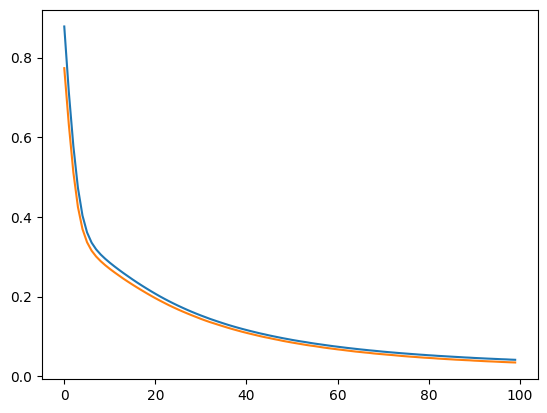

In [16]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')       

In [17]:
nuevo = pd.read_excel("GERENCIA DE AMBIENTE #2 (1).xlsx", sheet_name="A", header=0)

In [18]:
nuevo

,Identidad,Num. Ficha,Nombre Empleado,Departamento,Gerecia,Terminal,Fecha,Hora de Marcaje
0,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,07:02:15
1,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,16:34:45
2,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,07:03:29
3,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,16:35:18
4,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-20,07:00:48
...,...,...,...,...,...,...,...,...
4598,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-25,16:05:21
4599,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:51:41
4600,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:56:46
4601,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-28,08:16:46


In [19]:
Id = nuevo["Identidad"]
fecha = nuevo["Fecha"]
Hora_Entrada = nuevo["Hora de Marcaje"]

In [20]:
# Asegurarte de que las columnas tengan el formato correcto
Hora_Entrada = pd.to_datetime(Hora_Entrada, errors='coerce', format='mixed').dt.time
fecha = pd.to_datetime(fecha, errors='coerce', format='%d/%m/%Y').dt.date


In [21]:
Hora_Minima = nuevo.groupby(['Identidad', 'Fecha'])['Hora de Marcaje'].min().reset_index()

In [22]:
nuevo

,Identidad,Num. Ficha,Nombre Empleado,Departamento,Gerecia,Terminal,Fecha,Hora de Marcaje
0,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,07:02:15
1,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,16:34:45
2,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,07:03:29
3,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,16:35:18
4,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-20,07:00:48
...,...,...,...,...,...,...,...,...
4598,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-25,16:05:21
4599,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:51:41
4600,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:56:46
4601,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-28,08:16:46


In [23]:
nuevo['Hora Mínima'] = nuevo.groupby(['Identidad', 'Fecha'])['Hora de Marcaje'].transform('min')


In [25]:
nuevo

,Identidad,Num. Ficha,Nombre Empleado,Departamento,Gerecia,Terminal,Fecha,Hora de Marcaje,Hora Mínima
0,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,07:02:15,07:02:15
1,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,16:34:45,07:02:15
2,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,07:03:29,07:03:29
3,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,16:35:18,07:03:29
4,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-20,07:00:48,07:00:48
...,...,...,...,...,...,...,...,...,...
4598,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-25,16:05:21,08:24:26
4599,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:51:41,08:51:41
4600,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:56:46,08:51:41
4601,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-28,08:16:46,08:16:46


In [29]:
nuevo['Hora de Entrada'] = '07:30:00'

In [33]:
entrada = nuevo['Hora de Entrada'] 
minima = nuevo['Hora Mínima']

In [38]:
nuevo['Minutos Tarde'] = (
    (pd.to_timedelta(entrada.astype(str))-pd.to_timedelta(minima.astype(str)) )
    .dt.total_seconds() / 60
)


In [39]:
nuevo

,Identidad,Num. Ficha,Nombre Empleado,Departamento,Gerecia,Terminal,Fecha,Hora de Marcaje,Hora Mínima,Hora de Entrada,Minutos Tarde
0,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,07:02:15,07:02:15,07:30:00,27.750000
1,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,16:34:45,07:02:15,07:30:00,27.750000
2,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,07:03:29,07:03:29,07:30:00,26.516667
3,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,16:35:18,07:03:29,07:30:00,26.516667
4,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-20,07:00:48,07:00:48,07:30:00,29.200000
...,...,...,...,...,...,...,...,...,...,...,...
4598,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-25,16:05:21,08:24:26,07:30:00,-54.433333
4599,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:51:41,08:51:41,07:30:00,-81.683333
4600,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:56:46,08:51:41,07:30:00,-81.683333
4601,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-28,08:16:46,08:16:46,07:30:00,-46.766667


In [41]:
x_nuevo = nuevo[["Minutos Tarde"]]

In [45]:
x_nuevo_scaled = scaler.transform(x_nuevo)

In [46]:
prediccion = model.predict(x_nuevo_scaled)  

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step


In [48]:
nuevo['Marcador'] = (prediccion >= 0.5).astype(int)

In [50]:
nuevo 

,Identidad,Num. Ficha,Nombre Empleado,Departamento,Gerecia,Terminal,Fecha,Hora de Marcaje,Hora Mínima,Hora de Entrada,Minutos Tarde,Marcador
0,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,07:02:15,07:02:15,07:30:00,27.750000,1
1,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-18,16:34:45,07:02:15,07:30:00,27.750000,1
2,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,07:03:29,07:03:29,07:30:00,26.516667,1
3,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-19,16:35:18,07:03:29,07:30:00,26.516667,1
4,1613-1979-00866,MSPS-001671,ABELARDO MONTES MANZANO,AUDITORIA AMBIENTAL,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-20,07:00:48,07:00:48,07:30:00,29.200000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4598,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-25,16:05:21,08:24:26,07:30:00,-54.433333,0
4599,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:51:41,08:51:41,07:30:00,-81.683333,0
4600,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-26,08:56:46,08:51:41,07:30:00,-81.683333,0
4601,0801-1961-04381,MSPS-001902,ZABLAH AYALA LUTFI EDUARDO,DEPARTAMENTO DE SERVICIOS LEGALES DEL AMBIENTE,GERENCIA DE AMBIENTE,Gerencia de Ambiente #2,2025-08-28,08:16:46,08:16:46,07:30:00,-46.766667,0


In [51]:
nuevo.to_csv("Predicciones_Llegadas.csv", index=False, encoding="utf-8-sig")
print("✅ Archivo generado: Predicciones_Llegadas.csv")

✅ Archivo generado: Predicciones_Llegadas.csv


In [52]:
#LO LOGRAMOOOOOOOOOOS